# Function 3 Analysis - Week 2

This notebook contains the exploratory analysis for **Function 3** in Week 2. We now work with **11 datapoints**, integrating last week's query into the dataset, and continue to rely on Bayesian optimisation for guidance.

**Function Description:** 	
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 


## Loading and Displaying the Data

We load the inputs and outputs for function 3 and display them in a table format to inspect the raw data values. All inputs remain standardised in [0,1] and we still have the same x3 outlier, but now we also observe how the new point behaves: despite sitting near the “sweet spot” suggested by the GP, it yielded a slightly negative reward, reminding us how noisy this transformed objective can be.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
new_x = np.array([[0.403500, 0.382200, 0.489400]])
new_y = np.array([-0.011750816624169894])
X = np.vstack([X, new_x])
y = np.concatenate([y, new_y])
df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
df


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


- **New point (Week 1):** The `(~0.40, ~0.38, ~0.49)` query produced the best output yet at -0.011751.


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, and y). This helps identify linear relationships. We note a high correlation between x1 and x2. We will see later that there is a line of high output points when x1 and x2 are similar in magnitude. 


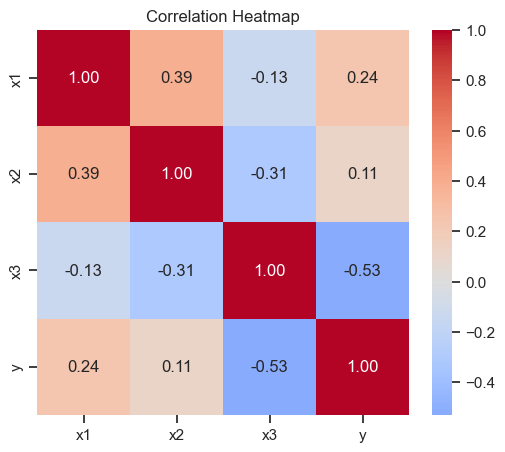

In [2]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()  

## Pairplot Analysis

The pairplot provides a comprehensive view of pairwise relationships between all variables (excluding datapoint 6 which is somewhat of an outlier and distorts the visual). The diagonal shows distributions (histograms), while off-diagonal plots show scatter plots. This helps identify patterns, clusters, and potential non-linear relationships that might not be captured by correlation alone.


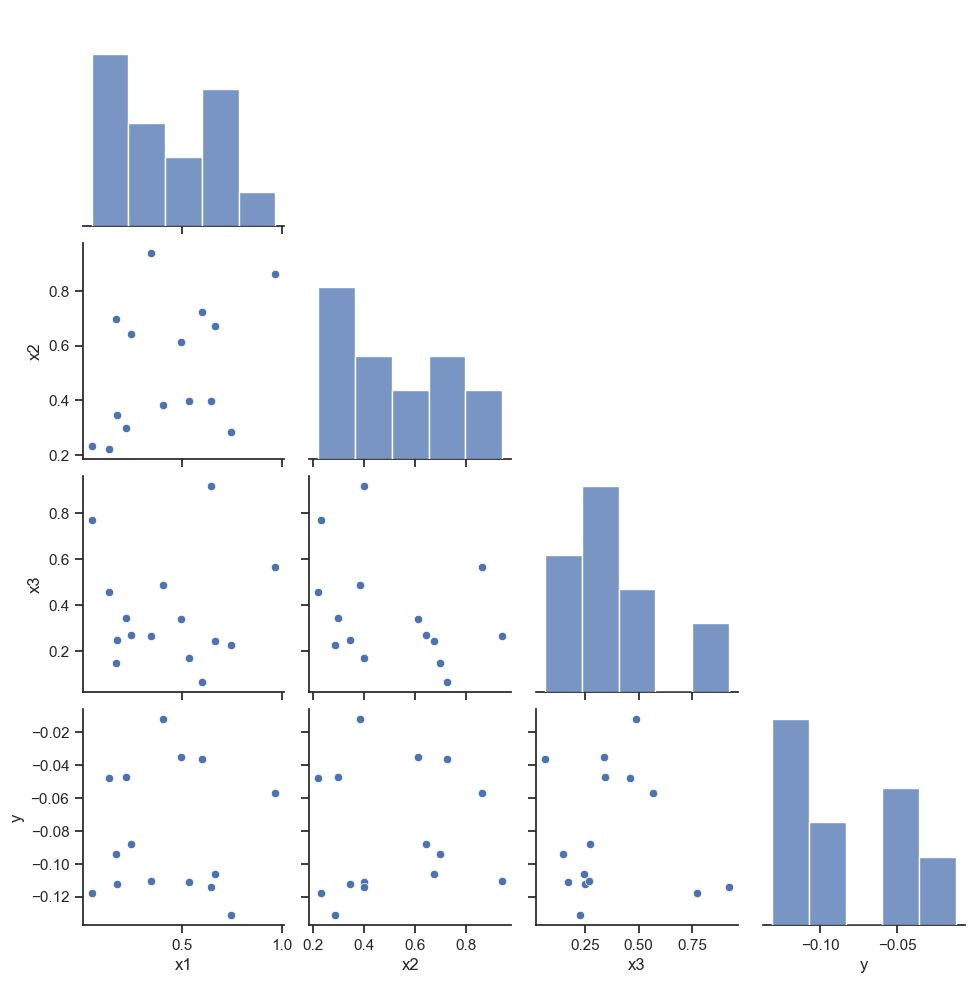

In [3]:
sns.pairplot(df.drop(index=6), corner=True, diag_kind="hist")
plt.show()


## Conclusion from Exploratory Analysis

From the correlation matrix and pairplot, we observe that there are no obvious strong linear correlations between the input variables and the output. This suggests the function has complex, non-linear relationships or interactions between the three compounds. Given this complexity, Bayesian optimization is well-suited as it can model non-linear relationships and balance exploration of unknown regions with exploitation of promising areas.


## Bayesian optimisation (expected improvement)

We use the **expected improvement (EI)** acquisition function to balance exploitation with the magnitude of potential gains. EI converts the GP posterior (mean `μ`, std `σ`) into the expected value of improvement over the incumbent best `y_best`, accounting for both the probability of beating that value *and* how much better we might do. The formula is:

**EI(x) = (μ(x) − y_best − ξ) · Φ(Z) + σ(x) · φ(Z)**  
where **Z = (μ(x) − y_best − ξ) / σ(x)**, Φ is the normal CDF, and φ is the normal PDF.

Unlike pure probability of improvement (which only asks "will we beat y_best?"), EI rewards high variance in promising regions, naturally balancing exploitation and exploration. The parameter **ξ = 0.03** is set larger than the typical near-zero value to encourage more exploratory behaviour: by requiring a more substantial improvement threshold, EI shifts weight toward high-uncertainty regions where the `σ · φ(Z)` term dominates. The workflow below:

1. Fits a 3D Matern kernel on `[x1, x2, x3]` with 16 observed points.
2. Evaluates a dense grid over `[0,1]^3`, computes EI at each node, and highlights the maximiser.

The resulting `candidate_df` lists the highest-EI locations; rerun the cell after adding new data to refresh the ranking and visualizations.


In [4]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Train a GP surrogate with bounds that avoid convergence warnings
kernel = ConstantKernel(1.0, (1e-2, 50.0)) * Matern(length_scale=[0.3, 0.3, 0.3], length_scale_bounds=(1e-2, 5.0), nu=1.5) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X, y)

# Evaluate a dense grid of candidates inside the [0, 1]^3 design space
grid_size = 40  # 40^3 = 64,000 points
grid_x1 = np.linspace(0.05, 0.95, grid_size)
grid_x2 = np.linspace(0.05, 0.95, grid_size)
grid_x3 = np.linspace(0.05, 0.95, grid_size)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3)).reshape(3, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y.max()
xi = 0.03  # larger ξ encourages exploration by requiring meaningful improvement over incumbent

# Expected improvement acquisition function
def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2", "x3"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["ei"] = ei
next_point = candidate_df.loc[candidate_df["ei"].idxmax()]

display(candidate_df.nlargest(5, "ei"))
print(f"\nSuggested next query (EI maximiser): ({next_point.x1:.3f}, {next_point.x2:.3f}, {next_point.x3:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,x3,mu,sigma,ei
26,0.050000,0.050000,0.65,-0.096550,0.088130,0.003990
1626,0.050000,0.073077,0.65,-0.096551,0.088105,0.003986
66,0.073077,0.050000,0.65,-0.096548,0.088104,0.003986
3226,0.050000,0.096154,0.65,-0.096551,0.088082,0.003982
106,0.096154,0.050000,0.65,-0.096546,0.088078,0.003982



Suggested next query (EI maximiser): (0.050, 0.050, 0.650)
Posterior mean: -0.0966, std: 0.0881, EI: 0.003990


## Visualization of EI Surface

We visualize the Expected Improvement surface across different 2D slices of the 3D input space. Each subplot shows a different projection (x1-x2, x1-x3, x2-x3) with the EI values computed at the slice through the recommended point's third coordinate. This helps understand where the acquisition function suggests exploring next relative to our current observations.


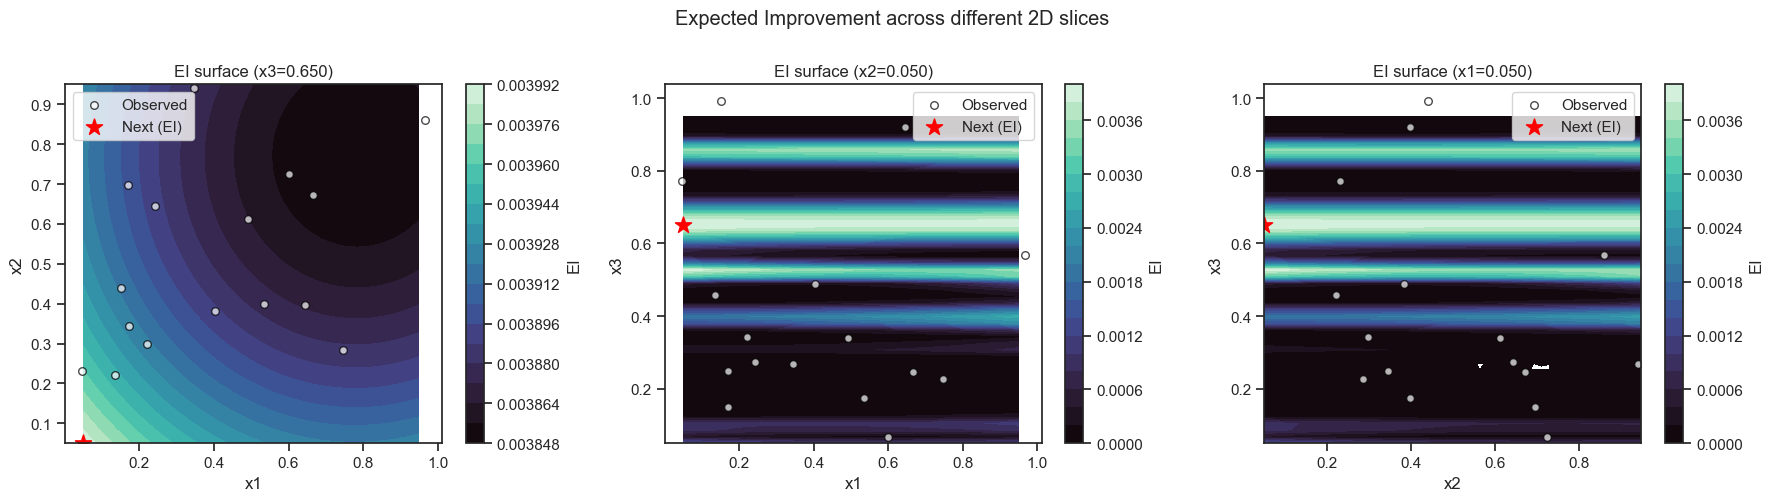

In [5]:
# Create 2D slices at the recommended point for visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# x1-x2 slice at x3=next_point.x3
grid_2d = 50
x1_vals = np.linspace(0.05, 0.95, grid_2d)
x2_vals = np.linspace(0.05, 0.95, grid_2d)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
slice_x3 = np.full(X1.ravel().shape, next_point.x3)
slice_mesh = np.column_stack([X1.ravel(), X2.ravel(), slice_x3])
mu_slice, sigma_slice = gp.predict(slice_mesh, return_std=True)
sigma_slice_safe = np.maximum(sigma_slice, 1e-9)
z_slice = (mu_slice - y_best - xi) / sigma_slice_safe
ei_slice = (mu_slice - y_best - xi) * norm_cdf(z_slice) + sigma_slice_safe * norm_pdf(z_slice)
ei_slice[sigma_slice <= 1e-9] = 0.0
EI_grid = ei_slice.reshape(X1.shape)

contour = axes[0].contourf(X1, X2, EI_grid, levels=20, cmap="mako")
axes[0].scatter(X[:, 0], X[:, 1], c="white", s=30, edgecolor="black", alpha=0.7, label="Observed")
axes[0].scatter(next_point.x1, next_point.x2, c="red", s=150, marker="*", label="Next (EI)")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title(f"EI surface (x3={next_point.x3:.3f})")
axes[0].legend(loc="best")
plt.colorbar(contour, ax=axes[0], label="EI")

# x1-x3 slice at x2=next_point.x2
x3_vals = np.linspace(0.05, 0.95, grid_2d)
X1, X3 = np.meshgrid(x1_vals, x3_vals)
slice_x2 = np.full(X1.ravel().shape, next_point.x2)
slice_mesh = np.column_stack([X1.ravel(), slice_x2, X3.ravel()])
mu_slice, sigma_slice = gp.predict(slice_mesh, return_std=True)
sigma_slice_safe = np.maximum(sigma_slice, 1e-9)
z_slice = (mu_slice - y_best - xi) / sigma_slice_safe
ei_slice = (mu_slice - y_best - xi) * norm_cdf(z_slice) + sigma_slice_safe * norm_pdf(z_slice)
ei_slice[sigma_slice <= 1e-9] = 0.0
EI_grid = ei_slice.reshape(X1.shape)

contour = axes[1].contourf(X1, X3, EI_grid, levels=20, cmap="mako")
axes[1].scatter(X[:, 0], X[:, 2], c="white", s=30, edgecolor="black", alpha=0.7, label="Observed")
axes[1].scatter(next_point.x1, next_point.x3, c="red", s=150, marker="*", label="Next (EI)")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x3")
axes[1].set_title(f"EI surface (x2={next_point.x2:.3f})")
axes[1].legend(loc="best")
plt.colorbar(contour, ax=axes[1], label="EI")

# x2-x3 slice at x1=next_point.x1
X2, X3 = np.meshgrid(x2_vals, x3_vals)
slice_x1 = np.full(X2.ravel().shape, next_point.x1)
slice_mesh = np.column_stack([slice_x1, X2.ravel(), X3.ravel()])
mu_slice, sigma_slice = gp.predict(slice_mesh, return_std=True)
sigma_slice_safe = np.maximum(sigma_slice, 1e-9)
z_slice = (mu_slice - y_best - xi) / sigma_slice_safe
ei_slice = (mu_slice - y_best - xi) * norm_cdf(z_slice) + sigma_slice_safe * norm_pdf(z_slice)
ei_slice[sigma_slice <= 1e-9] = 0.0
EI_grid = ei_slice.reshape(X2.shape)

contour = axes[2].contourf(X2, X3, EI_grid, levels=20, cmap="mako")
axes[2].scatter(X[:, 1], X[:, 2], c="white", s=30, edgecolor="black", alpha=0.7, label="Observed")
axes[2].scatter(next_point.x2, next_point.x3, c="red", s=150, marker="*", label="Next (EI)")
axes[2].set_xlabel("x2")
axes[2].set_ylabel("x3")
axes[2].set_title(f"EI surface (x1={next_point.x1:.3f})")
axes[2].legend(loc="best")
plt.colorbar(contour, ax=axes[2], label="EI")

plt.suptitle("Expected Improvement across different 2D slices", y=1.00)
plt.tight_layout()
plt.show()


## 3D Visualization of Recommended Point

We visualize the recommended EI maximiser in both 3D and 2D projections alongside the existing observations. This helps understand where the acquisition function suggests exploring next relative to our current data in the three-dimensional compound space. 


C:\Users\gophi\AppData\Local\Temp\ipykernel_54992\2502285868.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
C:\Users\gophi\AppData\Local\Temp\ipykernel_54992\2502285868.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")


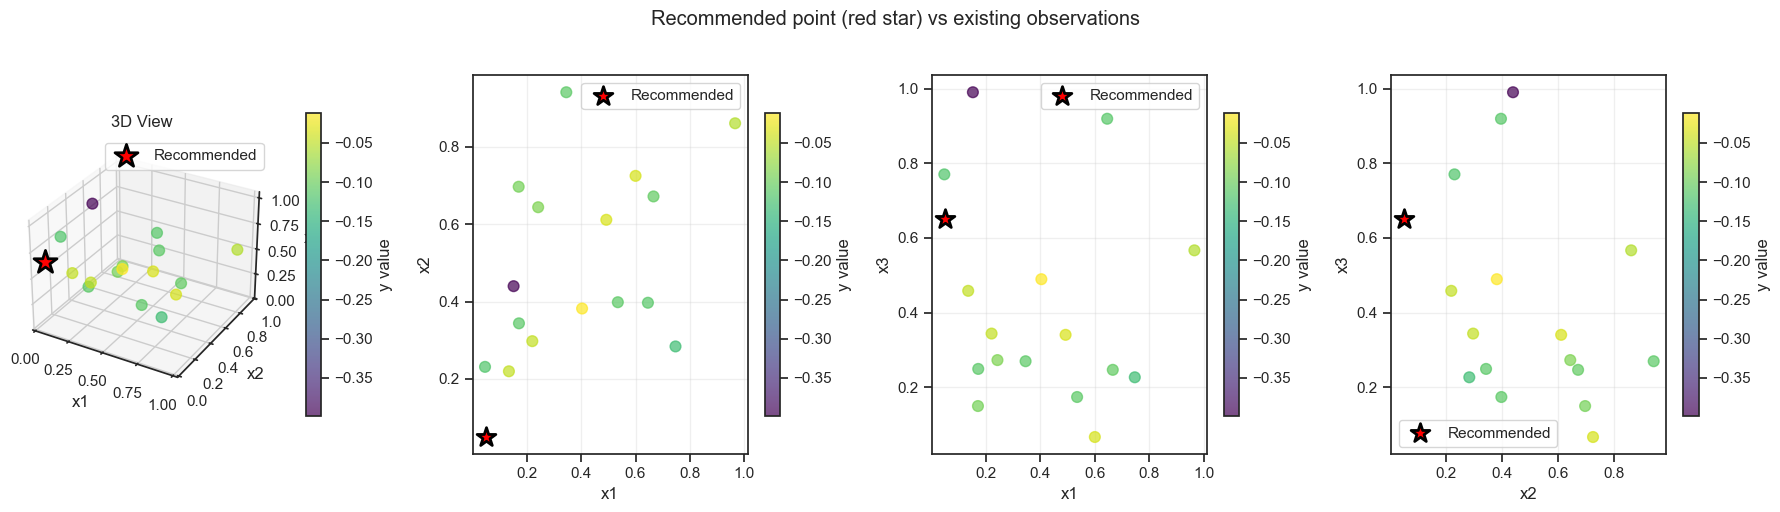

In [6]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(18, 5))
ax_3d = fig.add_subplot(141, projection='3d')
scatter_3d = ax_3d.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap="viridis", s=60, alpha=0.7)
ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
ax_3d.set_xlabel("x1")
ax_3d.set_ylabel("x2")
ax_3d.set_zlabel("x3")
ax_3d.legend()
ax_3d.set_title("3D View")
fig.colorbar(scatter_3d, ax=ax_3d, label="y value", shrink=0.8, pad=0.1)
axes = [fig.add_subplot(142), fig.add_subplot(143), fig.add_subplot(144)]
pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
for idx, (i, j, label_i, label_j) in enumerate(pairs):
    scatter2d = axes[idx].scatter(X[:, i], X[:, j], c=y, cmap="viridis", s=60, alpha=0.7)
    axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")
    axes[idx].set_xlabel(label_i)
    axes[idx].set_ylabel(label_j)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter2d, ax=axes[idx], label="y value", shrink=0.8)
plt.suptitle("Recommended point (red star) vs existing observations", y=1.02)
plt.tight_layout()
plt.show()


## Updated Analysis and Recommendation (EI)

The EI acquisition function uses an exploration parameter **ξ = 0.03** to balance exploitation of high-predicted regions with exploration of high-uncertainty areas. The GP learns directly from the three compound concentrations without additional feature engineering, allowing it to discover complex non-linear interactions between the inputs.

**Recommendation:** Query Function 3 at the EI maximiser coordinates shown in the output above (marked with red stars in the visualizations). This point offers the best expected improvement over the current best observation, balancing predicted response quality with uncertainty to efficiently explore the compound space.